In [6]:
#import statements
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import nilearn.image
import nilearn.plotting
import copy
from torch.utils.data import random_split
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from pathlib import Path
import ants
import pydicom
import nibabel as nib
import os
from glob import glob
from tqdm import tqdm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torchinfo import summary
import nilearn

In [2]:
# --- Load cohort CSVs --------------------------------------------------------
DATA = Path("model_data/adni")
SHORT_T1 = DATA / "t1_adc_short_data"
SHORT_DTI = DATA / "dti_adc_short_data"
meta_long = pd.read_csv(DATA / "paired_df_long.csv")
meta_short = pd.read_csv(DATA / "paired_df_short.csv")
# `meta` / `X_raw`: set in next cell to pooled long+short (defaults for rest of NB).
MODALITIES = ["t1_gm", "t1_wm", "t1_csf", "dti_gm", "dti_wm", "dti_csf"]

In [3]:
key_col = {
    "t1_gm": "t1_image_subject_id",
    "t1_wm": "t1_image_subject_id",
    "t1_csf": "t1_image_subject_id",
    "dti_gm": "dti_image_subject_id",
    "dti_wm": "dti_image_subject_id",
    "dti_csf": "dti_image_subject_id",
}
parquet_paths_long = {
    "t1_gm": DATA / "t1_long_data" / "t1_long_masked_gm.parquet",
    "t1_wm": DATA / "t1_long_data" / "t1_long_masked_wm.parquet",
    "t1_csf": DATA / "t1_long_data" / "t1_long_masked_csf.parquet",
    "dti_gm": DATA / "dti_long_data" / "dti_long_masked_gm_md.parquet",
    "dti_wm": DATA / "dti_long_data" / "dti_long_masked_wm_md.parquet",
    "dti_csf": DATA / "dti_long_data" / "dti_long_masked_csf_md.parquet",
}
parquet_paths_short = {
    "t1_gm": SHORT_T1 / "t1_short_masked_gm.parquet",
    "t1_wm": SHORT_T1 / "t1_short_masked_wm.parquet",
    "t1_csf": SHORT_T1 / "t1_short_masked_csf.parquet",
    "dti_gm": SHORT_DTI / "dti_short_masked_gm_adc.parquet",
    "dti_wm": SHORT_DTI / "dti_short_masked_wm_adc.parquet",
    "dti_csf": SHORT_DTI / "dti_short_masked_csf_adc.parquet",
}

X_raw_long = {
    k: pd.read_parquet(p).loc[meta_long[key_col[k]]].values.astype(np.float32)
    for k, p in parquet_paths_long.items()
}
X_raw_short = {
    k: pd.read_parquet(p).loc[meta_short[key_col[k]]].values.astype(np.float32)
    for k, p in parquet_paths_short.items()
}

In [4]:
# Create four y_hat groups for long dataset based on group and amyloid_label
long_cn_amyloid_1 = meta_long[(meta_long['group'] == 'CN') & (meta_long['amyloid_label'] == 1.0)]
long_cn_amyloid_0 = meta_long[(meta_long['group'] == 'CN') & (meta_long['amyloid_label'] == 0.0)]
long_dem_amyloid_1 = meta_long[(meta_long['group'] == 'Dementia') & (meta_long['amyloid_label'] == 1.0)]
long_dem_amyloid_0 = meta_long[(meta_long['group'] == 'Dementia') & (meta_long['amyloid_label'] == 0.0)]

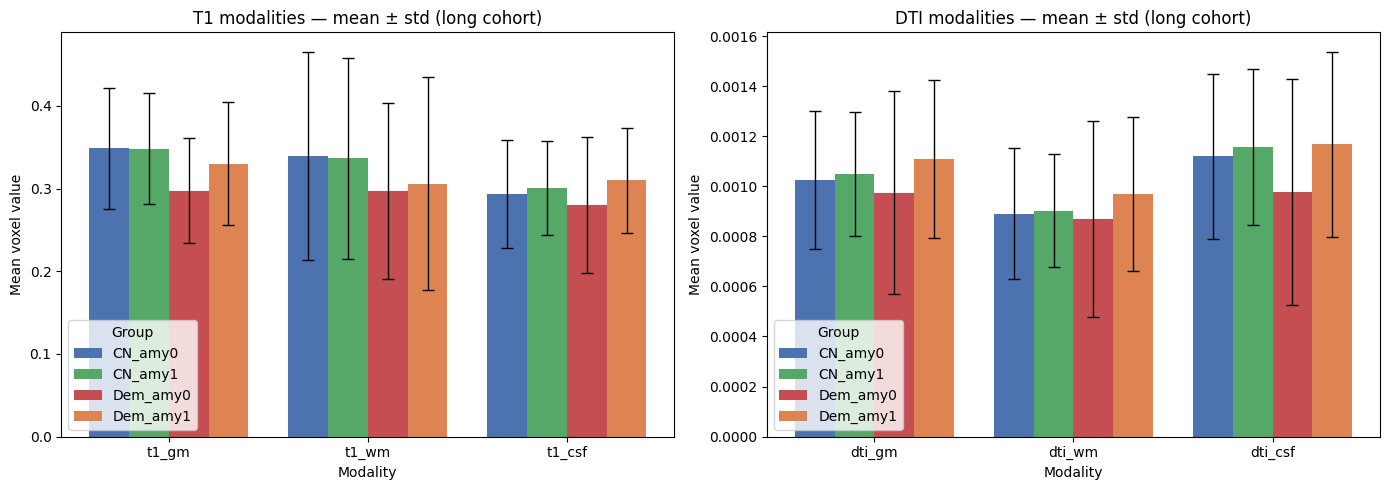

In [5]:
# Mean ± std voxel intensity per modality per group; separate T1 and DTI panels.

groups = {
    "CN_amy0":  long_cn_amyloid_0,
    "CN_amy1":  long_cn_amyloid_1,
    "Dem_amy0": long_dem_amyloid_0,
    "Dem_amy1": long_dem_amyloid_1,
}
colors = ["#4C72B0", "#55A868", "#C44E52", "#DD8452"]
T1_MODS  = ["t1_gm",  "t1_wm",  "t1_csf"]
DTI_MODS = ["dti_gm", "dti_wm", "dti_csf"]

# Compute per-subject mean across voxels, then group mean ± std across subjects
stats = {}
for grp_name, grp_meta in groups.items():
    idx = grp_meta.index.values
    stats[grp_name] = {
        mod: (
            float(X_raw_long[mod][idx].mean(axis=1).mean()),
            float(X_raw_long[mod][idx].mean(axis=1).std()),
        )
        for mod in MODALITIES
    }

def plot_panel(ax, mods, title):
    x = np.arange(len(mods))
    width = 0.2
    for i, (grp_name, color) in enumerate(zip(groups, colors)):
        means = [stats[grp_name][m][0] for m in mods]
        stds  = [stats[grp_name][m][1] for m in mods]
        ax.bar(x + i * width, means, width, yerr=stds, label=grp_name,
               color=color, capsize=4, error_kw={"elinewidth": 1})
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(mods)
    ax.set_xlabel("Modality")
    ax.set_ylabel("Mean voxel value")
    ax.set_title(title)
    ax.legend(title="Group")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
plot_panel(ax1, T1_MODS,  "T1 modalities — mean ± std (long cohort)")
plot_panel(ax2, DTI_MODS, "DTI modalities — mean ± std (long cohort)")
plt.tight_layout()
plt.show()


In [12]:
# MTL ROI column indices per tissue mask (GM/WM/CSF have different column counts).
# Atlas resampled to the same 1.5 mm grid used to build the parquets.

import nilearn.image, nibabel as nib, glob

_ref      = nib.load(sorted(glob.glob("model_data/adni/t1_long_data/t1_long_skull_strip/*.nii"))[0])
_atlas_res = nilearn.image.resample_to_img(nib.load("model_data/HO_cort_sub_combined.nii"), _ref, interpolation="nearest")
_atlas_flat = _atlas_res.get_fdata().flatten().astype(int)

MTL_ATLAS_LABELS = [58, 68, 59, 69, 36]  # L/R Hippocampus, L/R Amygdala, Parahippocampal post
_mtl_abs = np.where(np.isin(_atlas_flat, MTL_ATLAS_LABELS))[0]  # absolute voxel positions

def _mtl_cols_for_mask(mask_path):
    mask_res = nilearn.image.resample_to_img(nib.load(mask_path), _ref, interpolation="nearest")
    mask_pos = np.where(mask_res.get_fdata().flatten() > 0)[0]
    cols = np.searchsorted(mask_pos, _mtl_abs)
    cols = cols[cols < len(mask_pos)]
    cols = cols[mask_pos[cols] == _mtl_abs[:len(cols)]]
    return cols

mtl_cols_by_tissue = {
    "gm":  _mtl_cols_for_mask("model_data/mni_gm_mask.nii"),
    "wm":  _mtl_cols_for_mask("model_data/mni_wm_mask.nii"),
    "csf": _mtl_cols_for_mask("model_data/mni_csf_mask.nii"),
}
for t, c in mtl_cols_by_tissue.items():
    print(f"  MTL {t}: {len(c)} voxels")

# Map modality name -> tissue key
MOD_TISSUE = {
    "t1_gm": "gm", "t1_wm": "wm", "t1_csf": "csf",
    "dti_gm": "gm", "dti_wm": "wm", "dti_csf": "csf",
}


  MTL gm: 26155 voxels
  MTL wm: 10167 voxels
  MTL csf: 7144 voxels


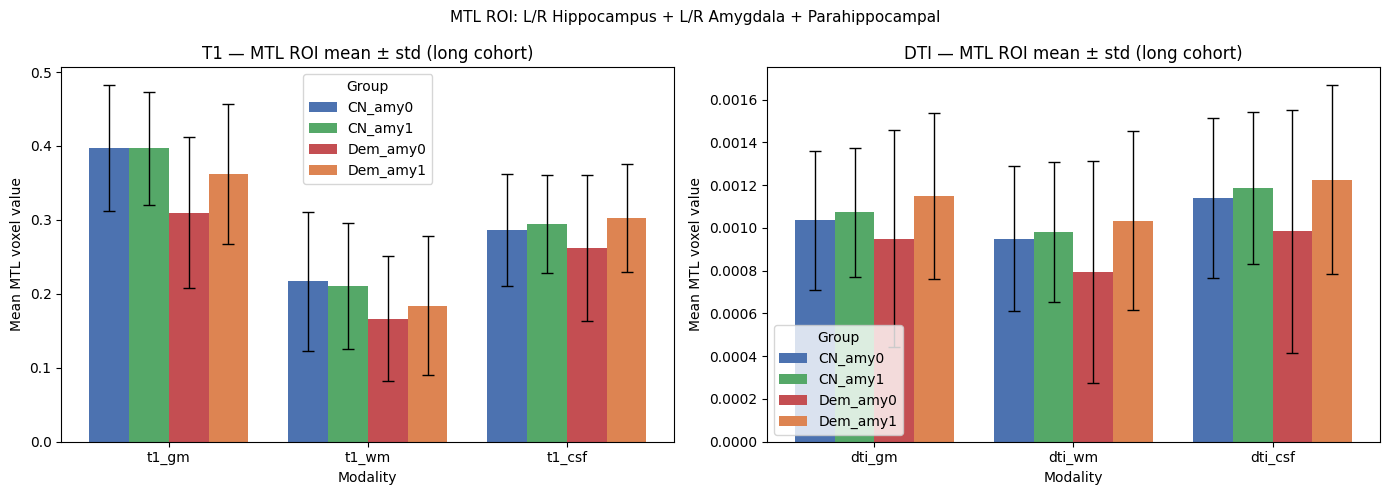

In [13]:
groups = {
    "CN_amy0":  long_cn_amyloid_0,
    "CN_amy1":  long_cn_amyloid_1,
    "Dem_amy0": long_dem_amyloid_0,
    "Dem_amy1": long_dem_amyloid_1,
}
colors  = ["#4C72B0", "#55A868", "#C44E52", "#DD8452"]
T1_MODS  = ["t1_gm",  "t1_wm",  "t1_csf"]
DTI_MODS = ["dti_gm", "dti_wm", "dti_csf"]

mtl_stats = {}
for grp_name, grp_meta in groups.items():
    idx = grp_meta.index.values
    mtl_stats[grp_name] = {
        mod: (
            float(X_raw_long[mod][np.ix_(idx, mtl_cols_by_tissue[MOD_TISSUE[mod]])].mean(axis=1).mean()),
            float(X_raw_long[mod][np.ix_(idx, mtl_cols_by_tissue[MOD_TISSUE[mod]])].mean(axis=1).std()),
        )
        for mod in T1_MODS + DTI_MODS
    }

def plot_mtl_panel(ax, mods, title):
    x = np.arange(len(mods))
    width = 0.2
    for i, (grp_name, color) in enumerate(zip(groups, colors)):
        means = [mtl_stats[grp_name][m][0] for m in mods]
        stds  = [mtl_stats[grp_name][m][1] for m in mods]
        ax.bar(x + i * width, means, width, yerr=stds, label=grp_name,
               color=color, capsize=4, error_kw={"elinewidth": 1})
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(mods)
    ax.set_xlabel("Modality")
    ax.set_ylabel("Mean MTL voxel value")
    ax.set_title(title)
    ax.legend(title="Group")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
plot_mtl_panel(ax1, T1_MODS,  "T1 — MTL ROI mean ± std (long cohort)")
plot_mtl_panel(ax2, DTI_MODS, "DTI — MTL ROI mean ± std (long cohort)")
fig.suptitle("MTL ROI: L/R Hippocampus + L/R Amygdala + Parahippocampal", fontsize=11)
plt.tight_layout()
plt.show()
